# 📊 Evaluation of Scam Detection Results

This notebook evaluates the predictions in `final_results.csv` using a **cutoff of 65** for binary classification.

**Columns:** `domain`, `is_scam` (ground truth), `prediction` (0–100 score), `reasoning`

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams["figure.dpi"] = 120

## 1 — Load & Inspect Data

In [40]:
df = pd.read_csv("final_results.csv")
df.dropna(subset=["is_scam", "prediction"], inplace=True)

print(f"Total samples : {len(df)}")
print(f"Scam (1)      : {(df['is_scam'] == 1).sum()}")
print(f"Legitimate (0): {(df['is_scam'] == 0).sum()}")
print()
df.head(10)

Total samples : 486
Scam (1)      : 7
Legitimate (0): 479



,domain,is_scam,prediction,reasoning
0,www.google.com,0,0.0,Content matches the official Google domain wit...
1,www.blogger.com,0,0.0,"Blogger.com is a well-known, legitimate bloggi..."
2,youtube.com,0,0.0,The webpage content matches the official YouTu...
3,linkedin.com,0,0.0,"This is the official LinkedIn website, a legit..."
4,support.google.com,0,0.0,This is the official Google Help Center websit...
5,cloudflare.com,0,0.0,The content matches the official Cloudflare do...
6,microsoft.com,0,0.0,"Content matches the official Microsoft domain,..."
7,apple.com,0,0.0,"Content matches official Apple domain, no gamb..."
8,en.wikipedia.org,0,0.0,The webpage is the official Wikipedia homepage...
9,play.google.com,0,0.0,The content matches the official Google Play d...


## 2 — Prediction Score Distribution

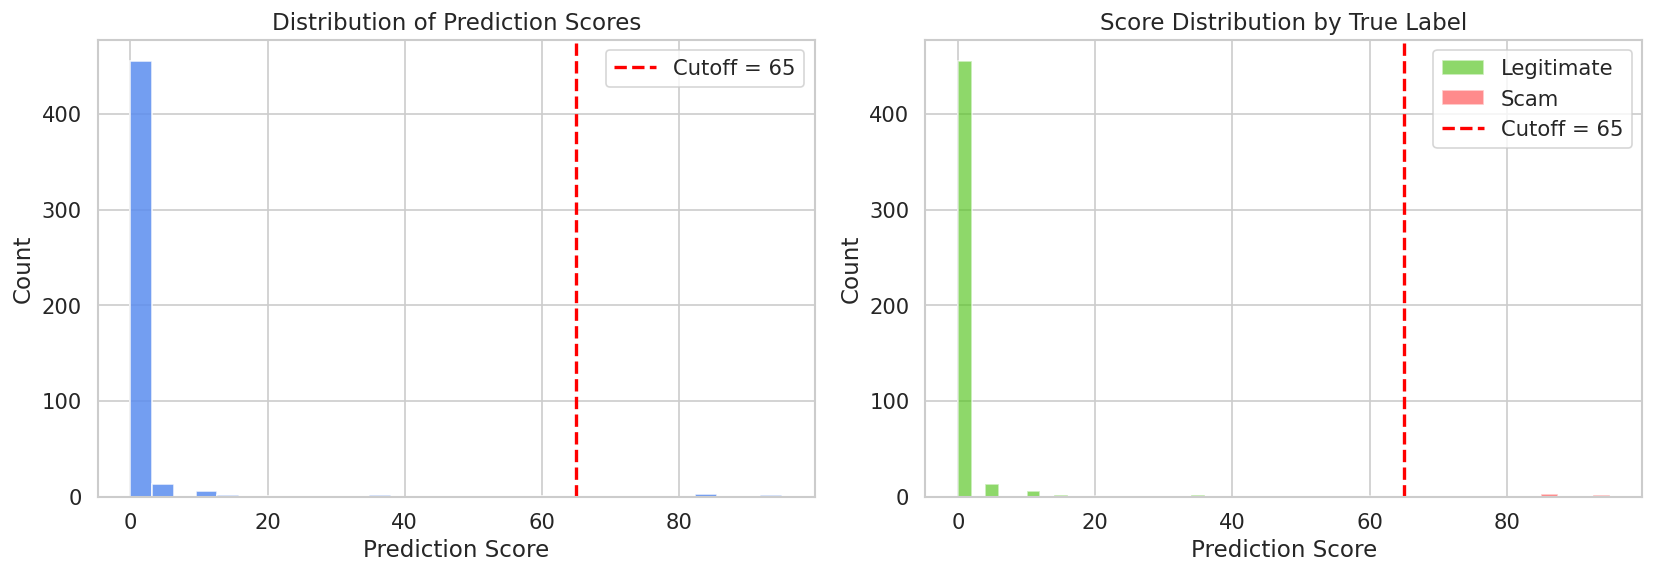

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Histogram of all scores ----
ax = axes[0]
ax.hist(df["prediction"], bins=30, edgecolor="white", color="#5B8DEF", alpha=0.85)
ax.axvline(65, color="red", linestyle="--", linewidth=2, label="Cutoff = 65")
ax.set_xlabel("Prediction Score")
ax.set_ylabel("Count")
ax.set_title("Distribution of Prediction Scores")
ax.legend()

# ---- Histogram by class ----
ax = axes[1]
for label, color, name in [(0, "#52C41A", "Legitimate"), (1, "#FF4D4F", "Scam")]:
    subset = df[df["is_scam"] == label]["prediction"]
    ax.hist(subset, bins=30, alpha=0.65, color=color, label=name, edgecolor="white")
ax.axvline(65, color="red", linestyle="--", linewidth=2, label="Cutoff = 65")
ax.set_xlabel("Prediction Score")
ax.set_ylabel("Count")
ax.set_title("Score Distribution by True Label")
ax.legend()

plt.tight_layout()
plt.show()

## 3 — ROC Curve

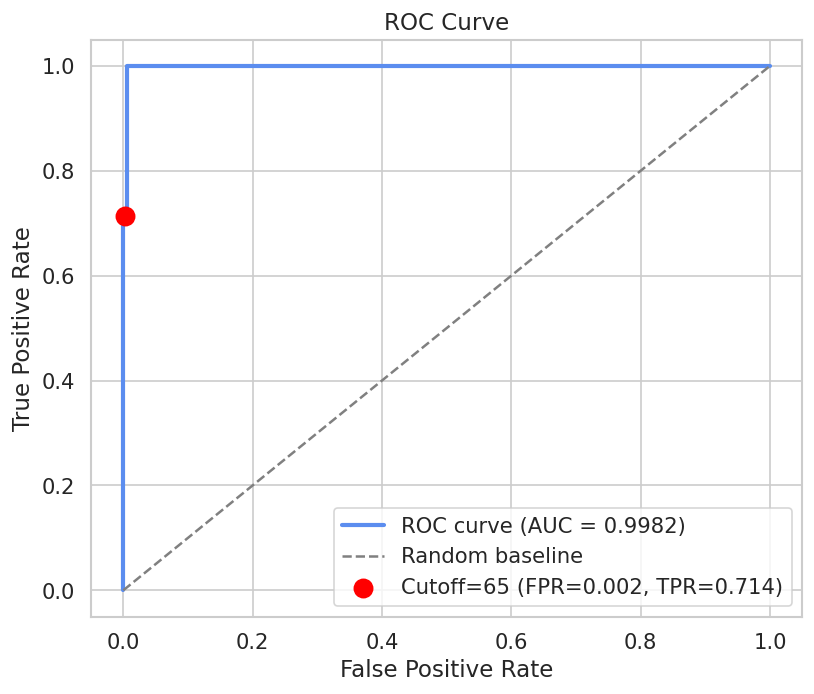

AUC-ROC: 0.9982


In [42]:
y_true = df["is_scam"].values
y_scores = df["prediction"].values / 100.0  # normalise to 0-1

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="#5B8DEF", lw=2.5, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="grey", lw=1.5, linestyle="--", label="Random baseline")

# Mark the cutoff = 65 point
cutoff_norm = 65 / 100.0
idx = np.argmin(np.abs(thresholds - cutoff_norm))
ax.scatter(fpr[idx], tpr[idx], s=120, color="red", zorder=5, label=f"Cutoff=65 (FPR={fpr[idx]:.3f}, TPR={tpr[idx]:.3f})")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"AUC-ROC: {roc_auc:.4f}")

## 4 — Precision-Recall Curve

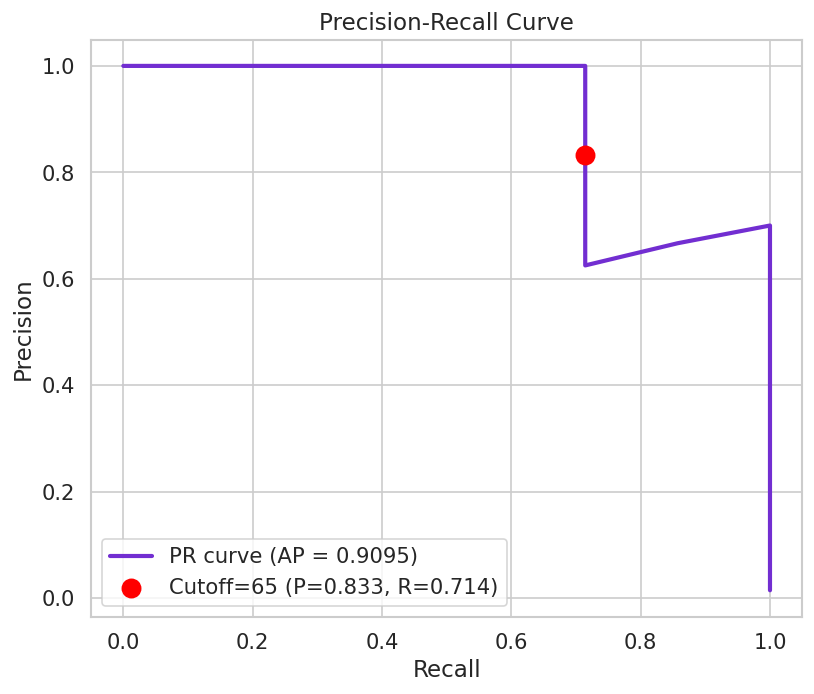

Average Precision (AP): 0.9095


In [43]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true, y_scores)
ap = average_precision_score(y_true, y_scores)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_curve, precision_curve, color="#722ED1", lw=2.5, label=f"PR curve (AP = {ap:.4f})")

# Mark cutoff = 65
idx_pr = np.argmin(np.abs(pr_thresholds - cutoff_norm))
ax.scatter(recall_curve[idx_pr], precision_curve[idx_pr], s=120, color="red", zorder=5,
           label=f"Cutoff=65 (P={precision_curve[idx_pr]:.3f}, R={recall_curve[idx_pr]:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Average Precision (AP): {ap:.4f}")

## 5 — Confusion Matrix (Cutoff = 65)

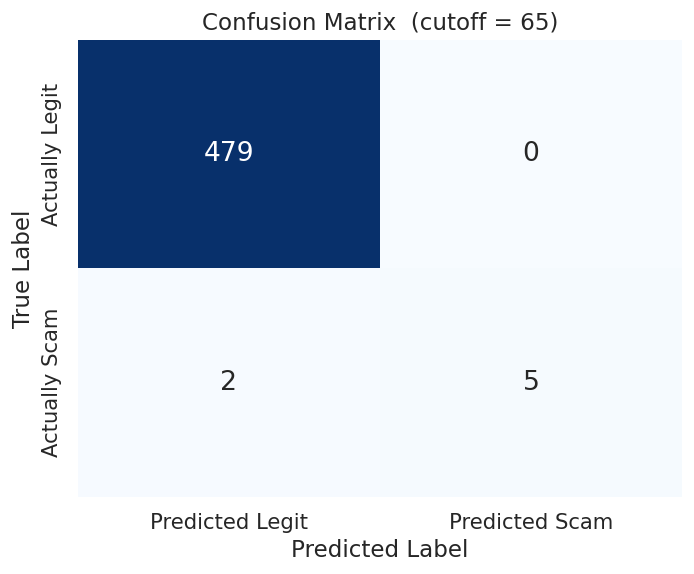

In [44]:
CUTOFF = 65
y_pred = (df["prediction"] >= CUTOFF).astype(int).values

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Legit", "Predicted Scam"],
            yticklabels=["Actually Legit", "Actually Scam"], ax=ax,
            annot_kws={"size": 16})
ax.set_title(f"Confusion Matrix  (cutoff = {CUTOFF})")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## 6 — Classification Metrics (Cutoff = 65)

In [45]:
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall (Sensitivity)": rec,
    "F1 Score": f1,
    "Specificity": specificity,
    "Negative Predictive Value": npv,
    "AUC-ROC": roc_auc,
    "Average Precision": ap,
}

metrics_df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"])
metrics_df["Value"] = metrics_df["Value"].map("{:.4f}".format)
metrics_df.style.hide(axis="index")

Metric,Value
Accuracy,0.9959
Precision,1.0000
Recall (Sensitivity),0.7143
F1 Score,0.8333
Specificity,1.0000
Negative Predictive Value,0.9958
AUC-ROC,0.9982
Average Precision,0.9095


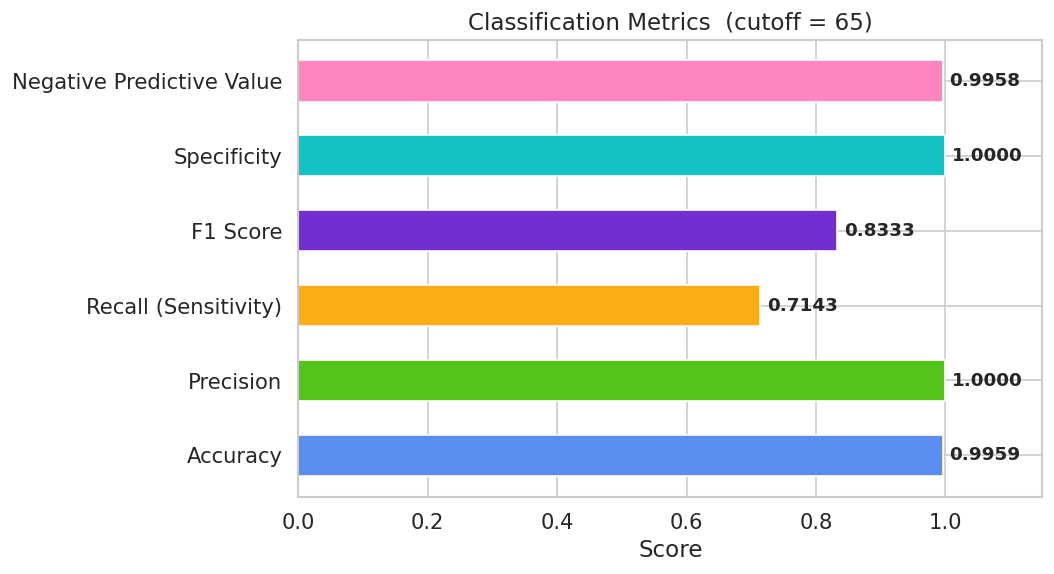

In [46]:
# Visual bar chart of key metrics
plot_metrics = {k: v for k, v in metrics.items() if k not in ["AUC-ROC", "Average Precision"]}

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#5B8DEF", "#52C41A", "#FAAD14", "#722ED1", "#13C2C2", "#FF85C0"]
bars = ax.barh(list(plot_metrics.keys()), list(plot_metrics.values()), color=colors, edgecolor="white", height=0.55)

for bar, val in zip(bars, plot_metrics.values()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontweight="bold", fontsize=11)

ax.set_xlim(0, 1.15)
ax.set_xlabel("Score")
ax.set_title(f"Classification Metrics  (cutoff = {CUTOFF})")
plt.tight_layout()
plt.show()

## 7 — Detailed Classification Report

In [47]:
print(classification_report(y_true, y_pred, target_names=["Legitimate", "Scam"], zero_division=0))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       479
        Scam       1.00      0.71      0.83         7

    accuracy                           1.00       486
   macro avg       1.00      0.86      0.92       486
weighted avg       1.00      1.00      1.00       486



## 8 — Metrics Across Different Cutoffs

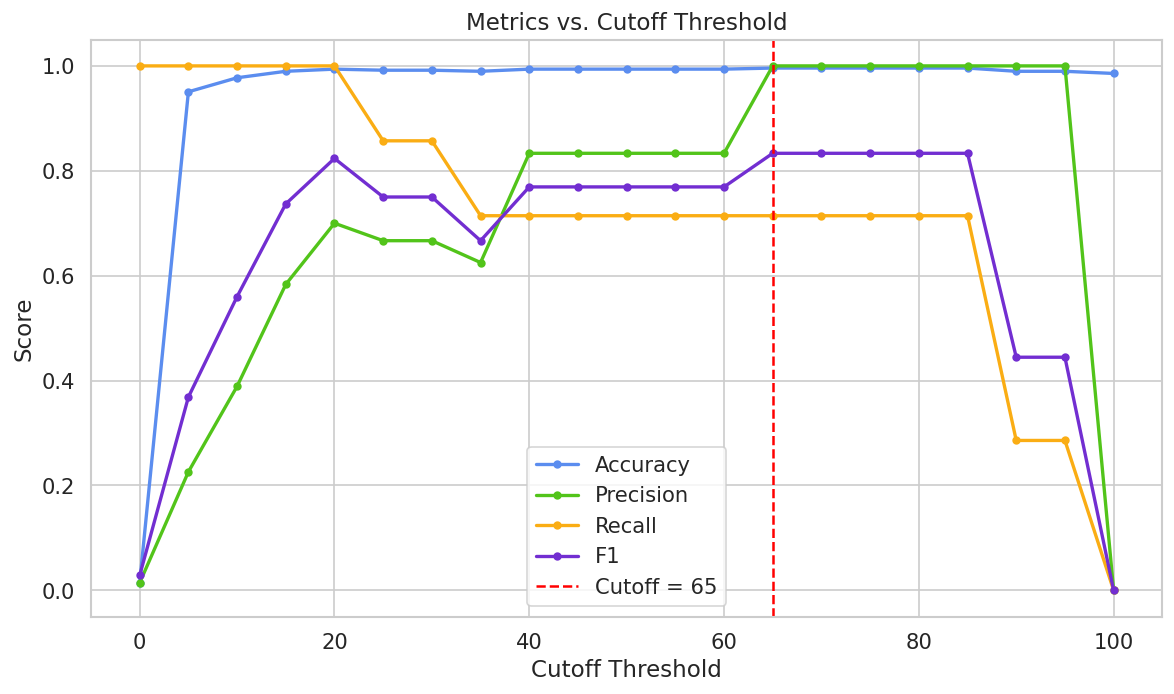

In [48]:
cutoffs = np.arange(0, 101, 5)
results = []

for c in cutoffs:
    yp = (df["prediction"] >= c).astype(int).values
    results.append({
        "Cutoff": c,
        "Accuracy": accuracy_score(y_true, yp),
        "Precision": precision_score(y_true, yp, zero_division=0),
        "Recall": recall_score(y_true, yp, zero_division=0),
        "F1": f1_score(y_true, yp, zero_division=0),
    })

cutoff_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 6))
for col, color in zip(["Accuracy", "Precision", "Recall", "F1"],
                       ["#5B8DEF", "#52C41A", "#FAAD14", "#722ED1"]):
    ax.plot(cutoff_df["Cutoff"], cutoff_df[col], marker="o", markersize=4, lw=2, label=col, color=color)

ax.axvline(65, color="red", linestyle="--", lw=1.5, label="Cutoff = 65")
ax.set_xlabel("Cutoff Threshold")
ax.set_ylabel("Score")
ax.set_title("Metrics vs. Cutoff Threshold")
ax.legend()
plt.tight_layout()
plt.show()

## 9 — Misclassified Samples (Cutoff = 65)

In [49]:
df["predicted_label"] = y_pred
misclassified = df[df["is_scam"] != df["predicted_label"]][["domain", "is_scam", "prediction", "reasoning"]]

print(f"Total misclassified: {len(misclassified)}")
print()

if len(misclassified) > 0:
    # False Positives (legit flagged as scam)
    fp_df = misclassified[misclassified["is_scam"] == 0]
    print(f"False Positives (legitimate flagged as scam): {len(fp_df)}")
    display(fp_df)
    print()

    # False Negatives (scam missed)
    fn_df = misclassified[misclassified["is_scam"] == 1]
    print(f"False Negatives (scam missed): {len(fn_df)}")
    display(fn_df)
else:
    print("No misclassifications!")

Total misclassified: 2

False Positives (legitimate flagged as scam): 0


,domain,is_scam,prediction,reasoning



False Negatives (scam missed): 2


,domain,is_scam,prediction,reasoning
477,www4.aldeee.com/pcgame/fps/764664.html,1,30.0,"Content does not match official WPS domain, cl..."
480,ca.spinspectacles.com,1,20.0,The page appears to be a gambling-related prom...


## 10 — Summary

| Item | Value |
|------|-------|
| **Dataset** | `final_results.csv` |
| **Cutoff** | 65 |
| **Key Visuals** | ROC, PR curve, confusion matrix, score distributions, metric sweep |